In [11]:
import os
from PIL import Image
from collections import Counter


def list_images(folder_path):
    return [
        f for f in os.listdir(folder_path)
        if f.endswith(('.png', '.jpg'))
    ]


def analyze_images(folder_path):
    widths, heights = [], []
    modes, formats = [], []

    files = list_images(folder_path)

    for file in files:
        img_path = os.path.join(folder_path, file)

        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                modes.append(img.mode)
                formats.append(img.format)
        except:
            continue

    return {
        "count": len(files),
        "avg_width": sum(widths) / len(widths) if widths else 0,
        "avg_height": sum(heights) / len(heights) if heights else 0,
        "min_width": min(widths) if widths else 0,
        "max_width": max(widths) if widths else 0,
        "min_height": min(heights) if heights else 0,
        "max_height": max(heights) if heights else 0,
        "channels": Counter(modes),
        "formats": Counter(formats),
    }


def review_mvtec_dataset(base_path):
    bottle_path = os.path.join(base_path, "bottle")

    print("=== DATASET + IMAGE REVIEW: MVTec AD (Bottle) ===\n")

    # ======================
    # TRAIN
    # ======================
    train_path = os.path.join(bottle_path, "train", "good")
    train_stats = analyze_images(train_path)

    print("Train (good):")
    print(f"  - Total images: {train_stats['count']}")
    print(f"  - Resolution (avg): {train_stats['avg_width']:.1f} x {train_stats['avg_height']:.1f}")
    print(f"  - Resolution (min-max): {train_stats['min_width']}–{train_stats['max_width']} x {train_stats['min_height']}–{train_stats['max_height']}")
    print(f"  - Channels: {dict(train_stats['channels'])}")
    print(f"  - Formats: {dict(train_stats['formats'])}")

    # ======================
    # TEST
    # ======================
    test_path = os.path.join(bottle_path, "test")
    categories = sorted(os.listdir(test_path))

    print("\nTest Dataset:")
    total_test = 0
    anomaly_types = []

    for cat in categories:
        cat_path = os.path.join(test_path, cat)

        if os.path.isdir(cat_path):
            stats = analyze_images(cat_path)
            total_test += stats["count"]

            print(f"\n  [{cat}]")
            print(f"    - Total: {stats['count']}")
            print(f"    - Avg Res: {stats['avg_width']:.1f} x {stats['avg_height']:.1f}")
            print(f"    - Channels: {dict(stats['channels'])}")

            if cat != "good":
                anomaly_types.append(cat)

    # ======================
    # GROUND TRUTH
    # ======================
    gt_path = os.path.join(bottle_path, "ground_truth")
    gt_categories = sorted(os.listdir(gt_path))

    print("\nGround Truth (Mask):")
    total_masks = 0

    for cat in gt_categories:
        cat_path = os.path.join(gt_path, cat)

        if os.path.isdir(cat_path):
            count = len(list_images(cat_path))
            total_masks += count
            print(f"  - {cat}: {count} masks")

    # ======================
    # SUMMARY
    # ======================
    print("\n=== SUMMARY ===")
    print(f"Train (good): {train_stats['count']}")
    print(f"Test (total): {total_test}")
    print(f"Total masks: {total_masks}")
    print(f"Anomaly types ({len(anomaly_types)}): {', '.join(anomaly_types)}")


if __name__ == "__main__":
    # 🔥 PATH SEMULA (ROOT DATASET)
    dataset_path = "D:\skripsi\self supervised\code\dataset\mvtec_anomaly_detection"  # contoh: D:/dataset/mvtec_ad

    review_mvtec_dataset(dataset_path)

=== DATASET + IMAGE REVIEW: MVTec AD (Bottle) ===

Train (good):
  - Total images: 209
  - Resolution (avg): 900.0 x 900.0
  - Resolution (min-max): 900–900 x 900–900
  - Channels: {'RGB': 209}
  - Formats: {'PNG': 209}

Test Dataset:

  [broken_large]
    - Total: 20
    - Avg Res: 900.0 x 900.0
    - Channels: {'RGB': 20}

  [broken_small]
    - Total: 22
    - Avg Res: 900.0 x 900.0
    - Channels: {'RGB': 22}

  [contamination]
    - Total: 21
    - Avg Res: 900.0 x 900.0
    - Channels: {'RGB': 21}

  [good]
    - Total: 20
    - Avg Res: 900.0 x 900.0
    - Channels: {'RGB': 20}

Ground Truth (Mask):
  - broken_large: 20 masks
  - broken_small: 22 masks
  - contamination: 21 masks

=== SUMMARY ===
Train (good): 209
Test (total): 83
Total masks: 63
Anomaly types (3): broken_large, broken_small, contamination


=== SAMPLE IMAGE REVIEW: MVTec AD (Bottle) ===

Train Sample (Good)


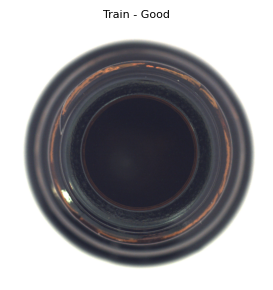


Test Sample (broken_large)


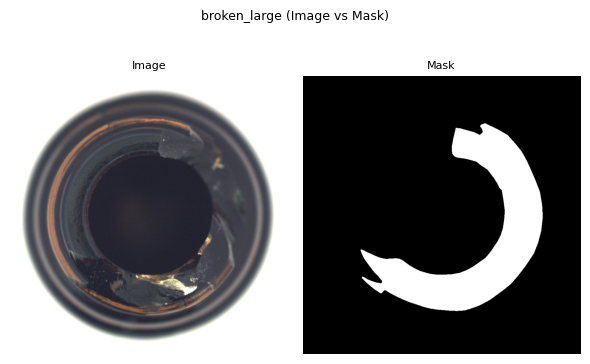


Test Sample (broken_small)


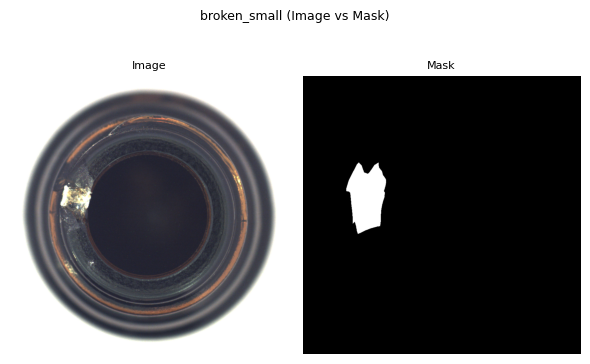


Test Sample (contamination)


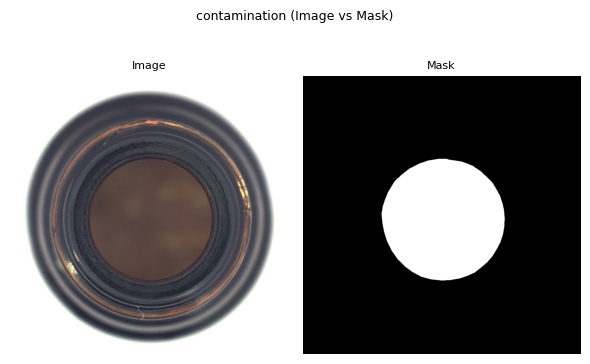


Test Sample (good)


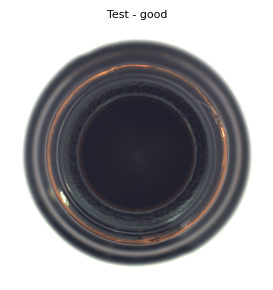

In [16]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt


# ======================
# GET RANDOM IMAGE + NAME
# ======================
def get_random_image_with_name(folder_path):
    files = [
        f for f in os.listdir(folder_path)
        if f.endswith(('.png', '.jpg'))
    ]

    if not files:
        return None, None

    file = random.choice(files)
    return os.path.join(folder_path, file), file


# ======================
# SHOW IMAGE ONLY
# ======================
def show_image(title, image_path):
    if image_path is None or not os.path.exists(image_path):
        print(f"{title}: No image found")
        return

    img = Image.open(image_path)

    # 🔥 kecilkan di sini
    plt.figure(figsize=(3, 3))

    plt.imshow(img)
    plt.title(title, fontsize=8)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# ======================
# SHOW IMAGE + MASK (SIDE BY SIDE)
# ======================
def show_image_and_mask(image_path, mask_path, title):
    if not os.path.exists(image_path):
        print("Image not found")
        return

    if not os.path.exists(mask_path):
        print("Mask not found")
        return

    img = Image.open(image_path)
    mask = Image.open(mask_path)

    # 🔥 ukuran diperkecil di sini
    plt.figure(figsize=(6, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Image", fontsize=8)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask", fontsize=8)
    plt.axis('off')

    plt.suptitle(title, fontsize=9)
    plt.tight_layout()
    plt.show()


# ======================
# MAIN FUNCTION
# ======================
def review_dataset_with_images(base_path):
    bottle_path = os.path.join(base_path, "bottle")

    print("=== SAMPLE IMAGE REVIEW: MVTec AD (Bottle) ===")

    # ======================
    # TRAIN SAMPLE
    # ======================
    train_good_path = os.path.join(bottle_path, "train", "good")
    train_img, _ = get_random_image_with_name(train_good_path)

    print("\nTrain Sample (Good)")
    show_image("Train - Good", train_img)

    # ======================
    # TEST SAMPLES
    # ======================
    test_path = os.path.join(bottle_path, "test")
    categories = sorted(os.listdir(test_path))

    for cat in categories:
        cat_path = os.path.join(test_path, cat)

        if not os.path.isdir(cat_path):
            continue

        print(f"\nTest Sample ({cat})")

        # ambil image + nama file
        img_path, filename = get_random_image_with_name(cat_path)

        # kalau good → hanya tampilkan gambar
        if cat == "good":
            show_image(f"Test - {cat}", img_path)

        else:
            # ======================
            # PAIR DENGAN MASK
            # ======================
            gt_path = os.path.join(bottle_path, "ground_truth", cat)

            if not os.path.exists(gt_path):
                print("Ground truth folder not found")
                continue

            # ubah nama file jadi mask
            name = os.path.splitext(filename)[0]
            mask_name = name + "_mask.png"
            mask_full_path = os.path.join(gt_path, mask_name)

            # tampilkan image + mask
            show_image_and_mask(
                img_path,
                mask_full_path,
                f"{cat} (Image vs Mask)"
            )


# ======================
# RUN
# ======================
if __name__ == "__main__":
    dataset_path = r"D:\skripsi\self supervised\code\dataset\mvtec_anomaly_detection"
    review_dataset_with_images(dataset_path)